## 01 Notebook Objective

The objective of this notebook is to understand the AI4I 2020 dataset before modeling.
We will inspect the dataset structure, identify the target variable, check data quality, and explore patterns related to machine failure.

## 02 Loading Dataset

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [6]:
df = pd.read_csv("../data/raw/ai4i2020.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 03 Data Set Understanding

In [7]:
df.shape

(10000, 14)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [25]:
# how is the distribution for numerical values?
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


1. UID: unique identifier ranging from 1 to 10000
2. product ID: consisting of a letter L, M, or H for low (50% of all 
products), medium (30%) and high (20%) as product quality variants and a variant-specific serial number
3. type: just the product type L, M or H from column 2
4. air temperature [K]: generated using a random walk process later normalized to a standard deviation of 2 K around 300 K
5. process temperature [K]: generated using a random walk process normalized to a standard deviation of 1 K, added to the air temperature plus 10 K.
6. rotational speed [rpm]: calculated from a power of 2860 W, overlaid with a normally distributed noise
torque [Nm]: torque values are normally distributed around 40 Nm with a SD = 10 Nm and no negative values.
7. torque [Nm]: torque values are normally distributed around 40 Nm with a SD = 10 Nm and no negative values.
8. tool wear [min]: The quality variants H/M/L add 5/3/2 minutes of tool wear to the used tool in the process.
9. a 'machine failure' label that indicates, whether the machine has failed in this particular datapoint for any of the following failure modes are true.
10. tool wear failure (TWF): the tool will be replaced of fail at a randomly selected tool wear time between 200 - 240 mins (120 times in our dataset). At this point in time, the tool is replaced 69 times, and fails 46 times (randomly assigned).
11. heat dissipation failure (HDF): heat dissipation causes a process failure, if the difference between air- and process temperature is below 8.6 K and the tools rotational speed is below 1380 rpm. This is the case for 115 data points.
12. power failure (PWF): the product of torque and rotational speed (in rad/s) equals the power required for the process. If this power is below 3500 W or above 9000 W, the process fails, which is the case 95 times in our dataset.
13. overstrain failure (OSF): if the product of tool wear and torque exceeds 11,000 minNm for the L product variant (12,000 M, 13,000 H), the process fails due to overstrain. This is true for 98 datapoints.
14. random failures (RNF): each process has a chance of 0,1 % to fail regardless of its process parameters. This is the case for only 19 datapoints, less than could be expected for 10,000 datapoints in our dataset



## 04 Target Variable Analysis

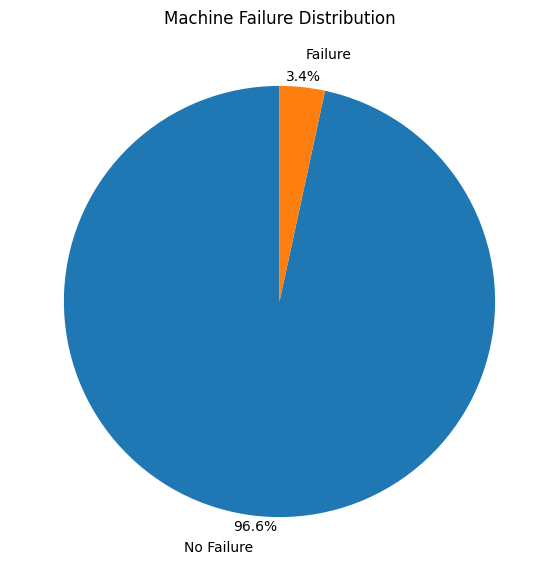

In [34]:
failure_counts = df["Machine failure"].value_counts().sort_index()

plt.figure(figsize=(7, 7))
plt.pie(
    failure_counts,
    labels=["No Failure", "Failure"],
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=1.05,   # moves percentage outward
    labeldistance=1.15   # moves labels outward
)
plt.title("Machine Failure Distribution")
plt.show()

In [63]:
failure_counts

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [23]:
df["Machine failure"].value_counts(normalize=True) * 100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

The target is imbalanced, with failure cases representing only in 3% of observations.

In [15]:
df.TWF.value_counts()

TWF
0    9954
1      46
Name: count, dtype: int64

In [16]:
df.HDF.value_counts()

HDF
0    9885
1     115
Name: count, dtype: int64

In [17]:
df.PWF.value_counts()

PWF
0    9905
1      95
Name: count, dtype: int64

In [18]:
df.OSF.value_counts()

OSF
0    9902
1      98
Name: count, dtype: int64

In [19]:
df.RNF.value_counts()

RNF
0    9981
1      19
Name: count, dtype: int64

In [64]:
failure_mode_cols = ["TWF", "HDF", "PWF", "OSF", "RNF"]

df["failure_mode_sum"] = df[failure_mode_cols].sum(axis=1)

df["failure_mode_sum"].value_counts().sort_index()

failure_mode_sum
0    9652
1     324
2      23
3       1
Name: count, dtype: int64

The sum of individual failure-mode labels exceeds the total number of machine failures, indicating that some observations are associated with more than one failure mode simultaneously. Therefore, the failure-mode columns should be interpreted as overlapping labels rather than mutually exclusive categories.

## 05 Data Quality Check

### Managing zeros

In [35]:
df.isna().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

### Managing Duplicates

In [41]:
df["UDI"].duplicated().sum()

np.int64(0)

In [42]:
df["Product ID"].duplicated().sum()

np.int64(0)

In [43]:
df.duplicated().sum()

np.int64(0)

There are no duplicated rows

## 06 Distributions and feature behavior

### Numerical Distributions

In [44]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols

['UDI',
 'Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'Machine failure',
 'TWF',
 'HDF',
 'PWF',
 'OSF',
 'RNF']

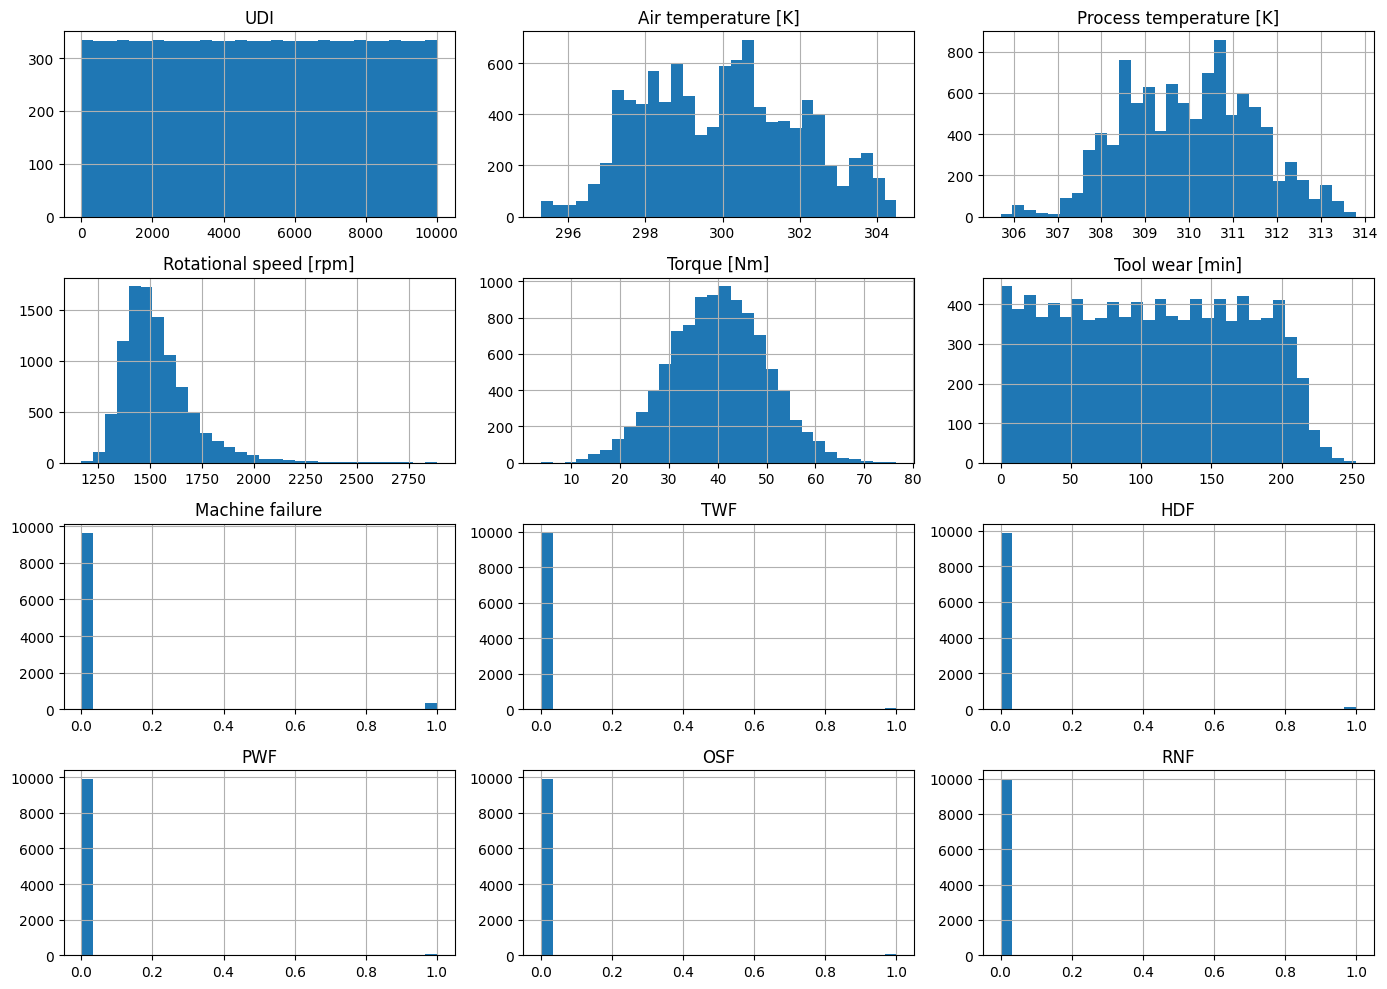

In [45]:
df[num_cols].hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

The dataset contains mostly non-failure observations, confirming that the prediction target is strongly imbalanced. The numerical features show different distribution shapes: rotational speed is right-skewed with rare high values, torque is approximately normally distributed, and tool wear is broadly and fairly evenly distributed. Air and process temperature vary within relatively narrow ranges. The failure-mode columns are also highly imbalanced and should be interpreted as rare outcome-related labels rather than input features.

### Boxplots for outliers

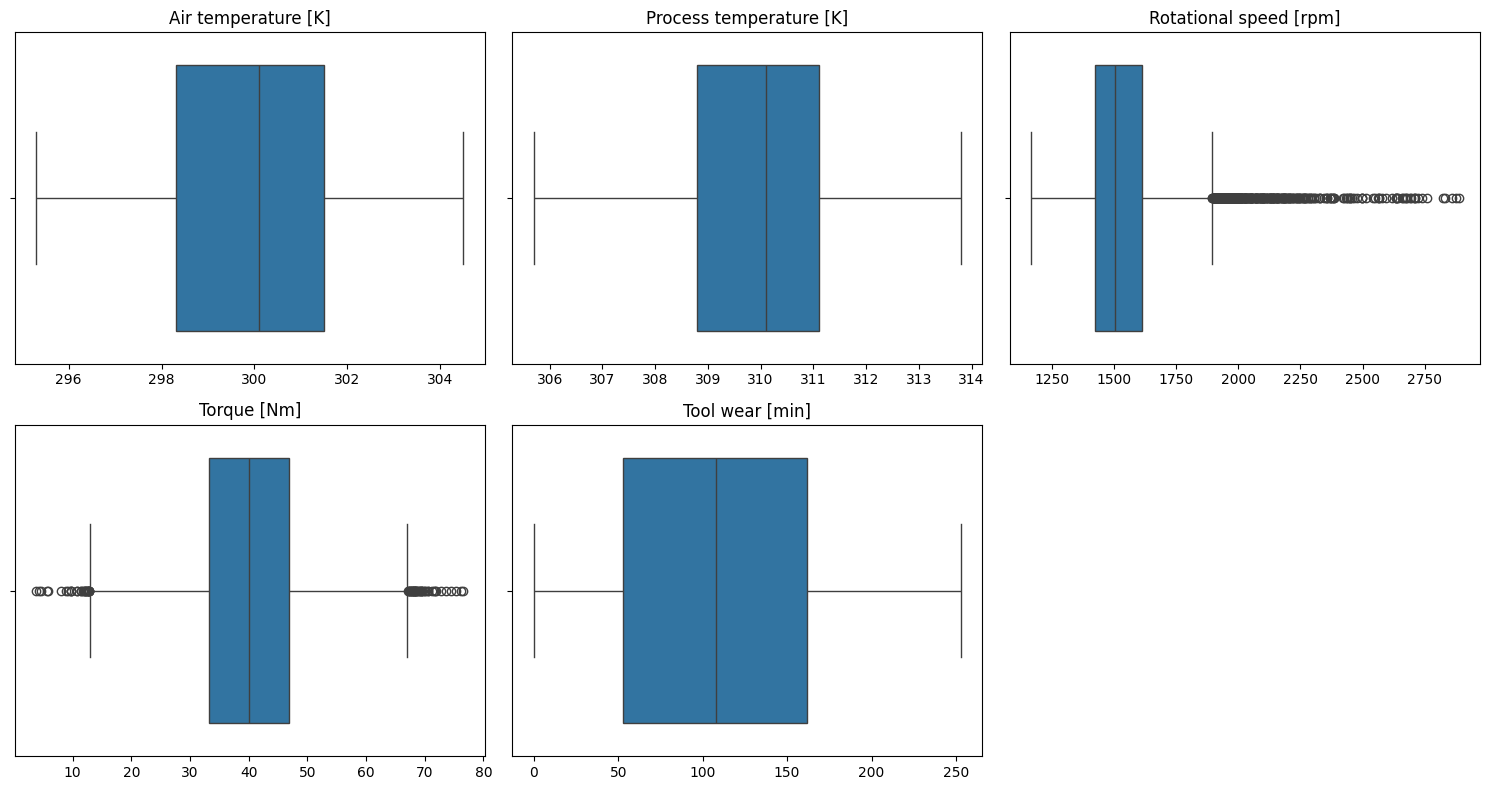

In [48]:
exclude_cols = ["UDI", "Machine failure", "TWF", "HDF", "PWF", "OSF", "RNF"]

boxplot_cols = [
    col for col in df.select_dtypes(include=np.number).columns
    if col not in exclude_cols
]

n_cols = 3
n_rows = (len(boxplot_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(boxplot_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

There could be some outliers on rotational speed

In [49]:
q1 = df["Rotational speed [rpm]"].quantile(0.25)
q3 = df["Rotational speed [rpm]"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[(df["Rotational speed [rpm]"] < lower_bound) | 
              (df["Rotational speed [rpm]"] > upper_bound)]

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", len(outliers))

outliers[["Rotational speed [rpm]", "Machine failure"]].head(20)

Lower bound: 1139.5
Upper bound: 1895.5
Number of outliers: 418


,Rotational speed [rpm],Machine failure
14,2035,0
50,2861,1
70,1924,0
101,1991,0
155,1987,0
172,1924,0
177,1988,0
194,2678,1
267,1954,0
284,2051,0


In [51]:
df[["Rotational speed [rpm]", "Machine failure"]].sort_values(
    by="Rotational speed [rpm]", ascending=False
).head(20)

,Rotational speed [rpm],Machine failure
1784,2886,1
463,2874,1
50,2861,1
847,2833,1
4296,2825,1
3369,2760,1
1391,2737,1
1095,2721,1
7997,2710,1
3867,2709,1


In [52]:
outliers["Machine failure"].value_counts(normalize=True) * 100

Machine failure
0    91.626794
1     8.373206
Name: proportion, dtype: float64

In [53]:
df["Machine failure"].value_counts(normalize=True) * 100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

Observations identified as rotational-speed outliers show a failure rate of about 8%, compared with about 3% in the full dataset. This suggests that these extreme values may represent meaningful operating conditions associated with increased failure risk, rather than simple data errors. So we won't remove them.

are the high rotation speeds related to a failure?

In [59]:
failure_cols = ["Machine failure", "TWF", "HDF", "PWF", "OSF", "RNF"]

(outliers[failure_cols].mean() * 100).round(2)

Machine failure    8.37
TWF                0.96
HDF                0.00
PWF                7.42
OSF                0.00
RNF                0.00
dtype: float64

In [60]:
non_outliers = df.drop(outliers.index)

(non_outliers[failure_cols].mean() * 100).round(2)

Machine failure    3.17
TWF                0.44
HDF                1.20
PWF                0.67
OSF                1.02
RNF                0.20
dtype: float64

In [61]:
failure_cols = ["Machine failure", "TWF", "HDF", "PWF", "OSF", "RNF"]

comparison = pd.DataFrame({
    "Non-outliers (%)": (non_outliers[failure_cols].mean() * 100).round(2),
    "Outliers (%)": (outliers[failure_cols].mean() * 100).round(2)
})

comparison

,Non-outliers (%),Outliers (%)
Machine failure,3.17,8.37
TWF,0.44,0.96
HDF,1.20,0.00
PWF,0.67,7.42
OSF,1.02,0.00
RNF,0.20,0.00


Rotational-speed outliers show substantially higher failure rates than non-outliers. The strongest increase is observed for Power Failure (PWF), rising from 0.67% in non-outliers to 7.42% in outliers. This suggests that extreme rotational-speed observations are particularly associated with PWF-related operating conditions and should not be removed without strong justification.

## 07 Feature Relationships and Correlations

### Correlation Matrix

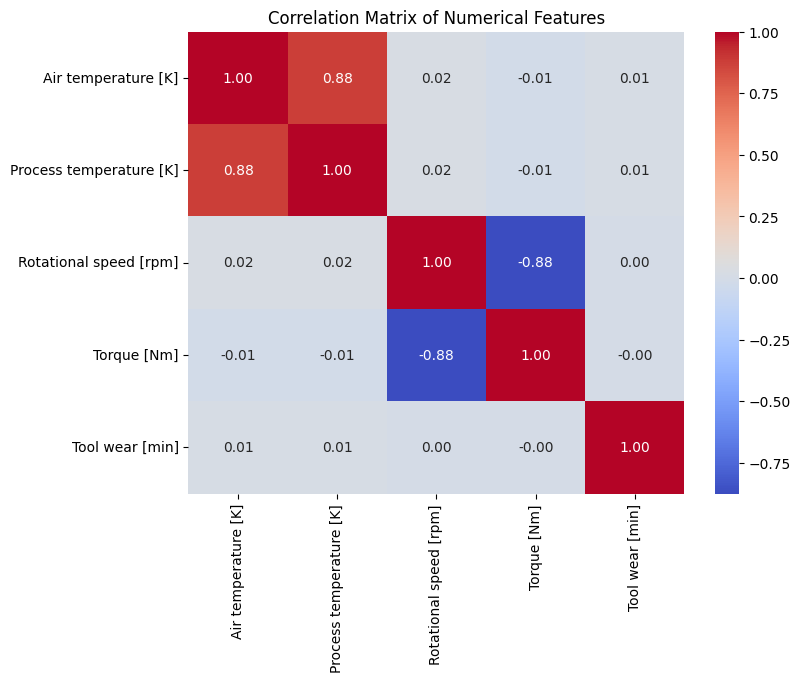

In [73]:
feature_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

plt.figure(figsize=(8, 6))
sns.heatmap(df[feature_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

The correlation analysis reveals two strong relationships among the numerical features. Air temperature and process temperature are strongly positively correlated (0.88), while rotational speed and torque are strongly negatively correlated (-0.88). Tool wear shows almost no linear correlation with the other numerical variables, suggesting that it may contribute complementary information for failure prediction.

### Comparation of numeric features by target

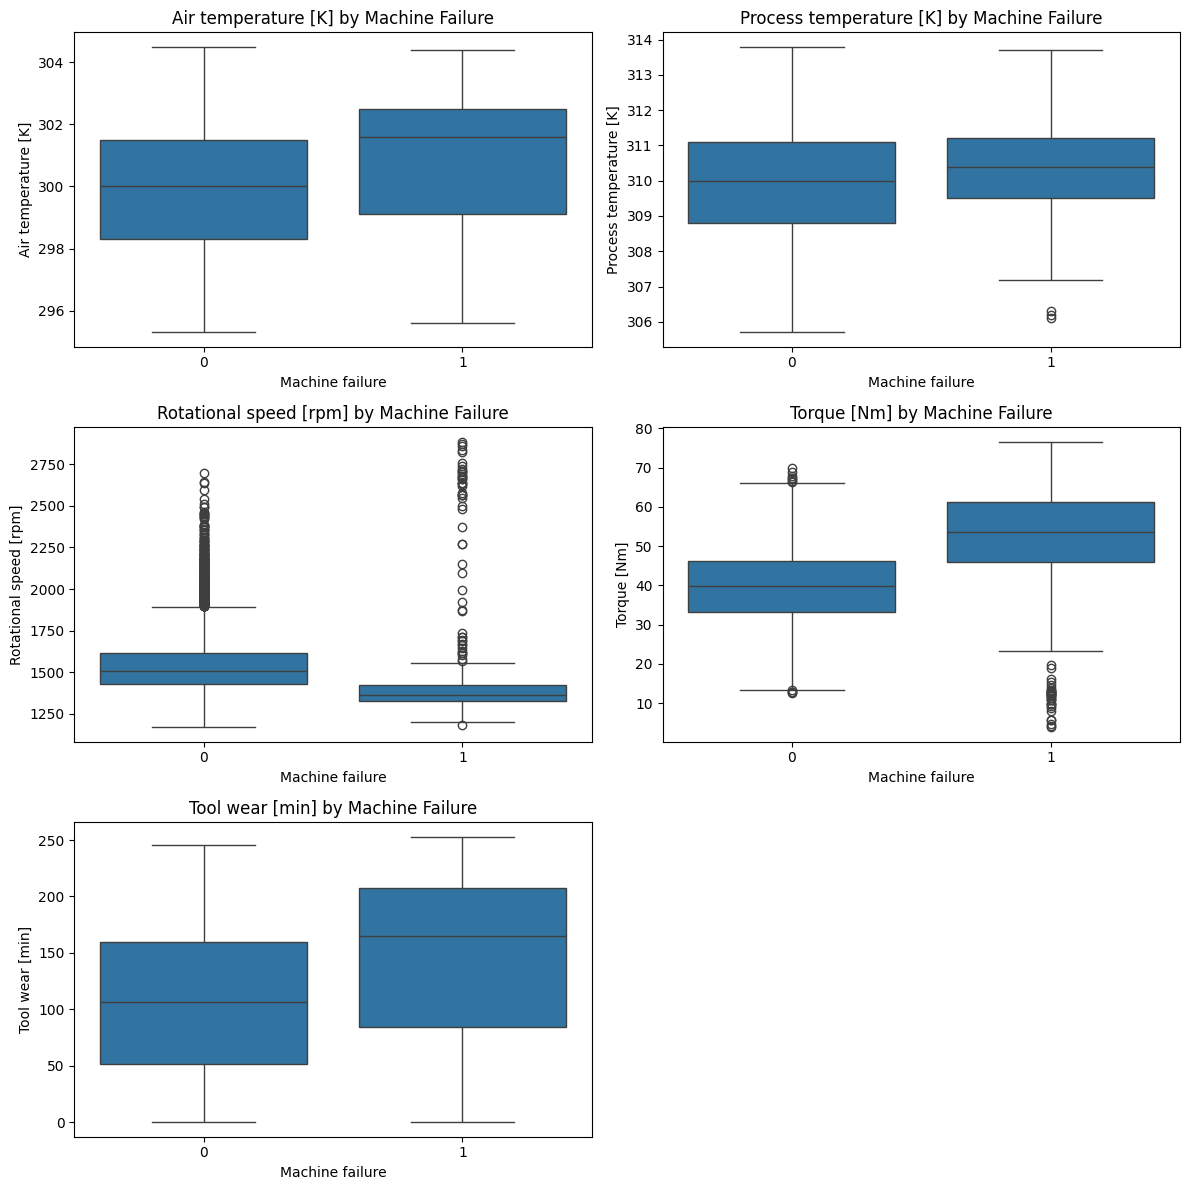

In [74]:
n_cols = 2
n_rows = (len(feature_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.boxplot(data=df, x="Machine failure", y=col, ax=axes[i])
    axes[i].set_title(f"{col} by Machine Failure")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

The boxplots suggest that machine failures are more frequently observed at higher torque values, higher tool wear levels, and slightly higher air and process temperatures. Failures also appear associated with lower rotational speeds, although this variable is more widely dispersed and shows substantial overlap between failure and non-failure cases. Among these variables, torque and tool wear show the clearest separation between the two groups.

### Compare machine failure rate by product type

In [76]:
type_failure_rate = df.groupby("Type")["Machine failure"].mean() * 100
type_failure_rate

Type
H    2.093719
L    3.916667
M    2.769436
Name: Machine failure, dtype: float64

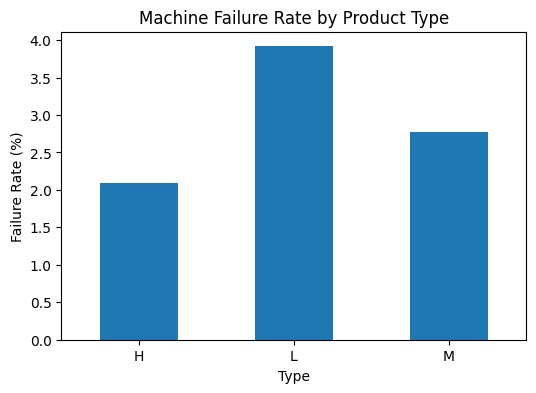

In [77]:
type_failure_rate.plot(kind="bar", figsize=(6, 4))
plt.title("Machine Failure Rate by Product Type")
plt.ylabel("Failure Rate (%)")
plt.xlabel("Type")
plt.xticks(rotation=0)
plt.show()

Machine failure rates are not evenly distributed across product types. Type L appears more failure-prone than the other variants, while type H shows the lowest failure rate. This indicates that product type may capture meaningful differences in operating conditions or failure thresholds and is likely to be a relevant predictor.

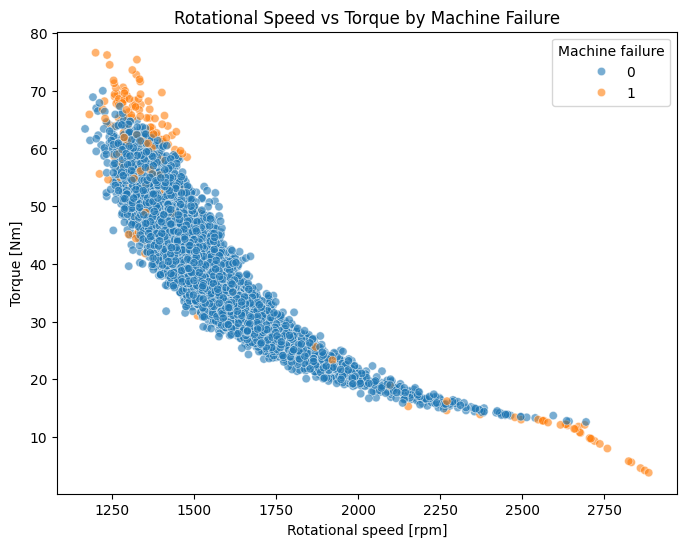

In [78]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="Rotational speed [rpm]",
    y="Torque [Nm]",
    hue="Machine failure",
    alpha=0.6
)
plt.title("Rotational Speed vs Torque by Machine Failure")
plt.show()

## 08 Initial Findings and Next Steps

- Our initial data set has 14 columns and 10000 entries.
- Source data information and data set were not consistent, was corrected
- Our target variable, the Machine Failure, has an imbalanced distribution. Only 3.7% of the entries have failed.
- The sum of the failure-mode labels is higher than the number of machine failures, which means that some observations have more than one failure mode. Therefore, the failure modes are overlapping labels, not mutually exclusive categories.
- Features Distributions (just from features affecting Target Variable):
    - Rotational speed is right-skewed
    - Torque looks approximately bell-shaped
    - Tool wear looks almost uniform over a broad range
    - Air temperature and process temperature look fairly concentrated
- There were not significant outliers detected
- Among the numerical features, air and process temperature are strongly positively correlated, while rotational speed and torque are strongly negatively correlated. In contrast, tool wear appears largely independent and may add complementary information for prediction. 
- Machine failures are most strongly associated with higher torque and tool wear, while weaker patterns are observed for temperature and lower rotational speed. Among the numerical features, torque and tool wear show the clearest distinction between failed and non-failed cases.
- The failure rate differs across product types. Type L shows the highest machine failure rate, followed by type M, while type H has the lowest failure rate. This suggests that product type may be informative for failure prediction and should be retained as a feature in the modeling stage.
